In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
from glob import glob
import os
import seaborn as sns

In [3]:
paths = {
    # "Sarcoma+AFS": "output/sarcoma+icl+ppo+long_horizon+no_augment/2026-04-10-19-46-46/sarcoma__agentTrue_ablation.csv",
    # "Sarcoma+FIFO": "output/sarcoma+icl+no_agent+long_horizon+no_augment/2026-04-10-19-47-31/sarcoma__agentFalse_ablation.csv",
    "MSD-Heart+FIFO":"output/msd_task02+no_agent+icl+no_augment/2026-04-03-19-32-08/msd_Task02_agentFalse_ablation.csv",
    "MSD-Heart+AFS":"output/msd_task02+icl+grpo+lazy_pen1.0+long_horizon+flip_augment/2026-04-23-16-01-08/msd_Task02_agentTrue_ablation.csv",
    # "MSD-Colon+FIFO":"output/msd_task10+icl+no_agent+long_horizon+no_augment/2026-04-12-15-52-38/msd_Task10_agentFalse_ablation.csv",
    # "MSD-Colon+AFS":"output/msd_task10+icl+ppo+long_horizon+no_augment/2026-04-17-18-39-30/msd_Task10_agentTrue_ablation.csv",
    # "MSD-Spleen+AFS":"output/msd_task09+icl+ppo+long_horizon+no_augment/2026-04-11-12-20-13/msd_Task09_agentTrue_ablation.csv",
    # "MSD-Spleen+FIFO": "output/msd_task09+icl+no_agent+long_horizon+no_augment/2026-04-11-12-19-00/msd_Task09_agentFalse_ablation.csv",
    # "MSD-Prostate+FIFO":"output/msd_task05+no_agent+long_horizon+no_augment/2026-04-13-18-04-27/msd_Task05_agentFalse_ablation.csv",
    # "MSD-Prostate+AFS":"output/msd_task05+ppo+long_horizon+no_augment/2026-04-13-14-13-19/msd_Task05_agentTrue_ablation.csv",
}

In [4]:
dfs = {}

for l, p in paths.items():
    print(l)
    df = pd.read_csv(p, index_col=0)
    dfs[l] = df

MSD-Heart+FIFO
MSD-Heart+AFS


In [5]:
for l, df in dfs.items():
    df["vol_id"] = df["id"].str.split("_").str[1].str.split(".").str[0].astype(np.int64)
    df["obj_id"] = df["id"].str.split("_").str[2].astype(np.int64)
    df["frame_id"] = df["id"].str.split("_").str[3].astype(np.int64)
    dfs[l] = df.set_index(["vol_id", "obj_id", "frame_id"])
    # dfs[l] = df.sort_values(["vol_id", "obj_id", "frame_id"])

In [6]:
for label, df in dfs.items():
    if "FIFO" in label:
        drop_delta = []
        for d, f in zip(df['delta'], df['drop_frame']):
            dices = eval(d)
            if f == -1:
                v = 0
            else:
                deltas = []
                for i, dice in dices.items():
                    if i == f:
                        continue
                    deltas.append(dices[f] - dice) # actual choice - other choices => higher means better
                
                v = np.max(deltas)
                
            drop_delta.append(v * 100)

        df['drop_delta'] = pd.Series(drop_delta, index=df.index)
    else:
        drop_delta = []
        for frame_id, (d, f) in zip(df['id'], zip(df['delta'], df['drop_frame'])):
            if f == -1:
                v = 0
            else:
                dices = eval(d)
                deltas = []
                for i, dice in dices.items():
                    if i == f:
                        continue
                    deltas.append(dices[f] - dice)  # actual choice - other choices => higher means better  

                if deltas:
                    v = np.max(deltas)
                else:
                    v = 0
                
            drop_delta.append(v * 100)

        df['drop_delta'] = pd.Series(drop_delta, index=df.index)

In [7]:
join_dfs = {}
mean_delta = {}
for dataset in np.unique([k.split("+")[0] for k in dfs.keys()]):
    rl_df = dfs[dataset+"+AFS"]
    fifo_df = dfs[dataset+"+FIFO"]
    join_df = rl_df.join(fifo_df, on=["vol_id", "obj_id", "frame_id"], lsuffix="_rl", rsuffix="_fifo")
    join_df['dice_diff'] = (join_df['dice_rl'] - join_df['dice_fifo']) * 100
    join_df['attn_diff'] = join_df['min_attn_rl'] - join_df['min_attn_fifo']
    join_df = join_df[join_df["drop_frame_fifo"] != -1]
    join_df = join_df[(join_df['dice_diff'] > join_df['dice_diff'].quantile(0.5))]
    # join_df = join_df[join_df['dice_diff'] < 5.0]
    
    # display(join_df)
    # print(join_df.loc[pd.MultiIndex.from_tuples([(30,1,65)], names=["vol_id","obj_id","frame_id"])]['delta_rl'].values[0])
    
    join_dfs[dataset] = join_df
    mean_delta[dataset+"+FIFO"] = join_df["drop_delta_fifo"]
    mean_delta[dataset+"+AFS"] = join_df["drop_delta_rl"]
    
# display(dfs["MSD-Heart+AFS"][dfs["MSD-Heart+AFS"]["id"] == "la_007.nii.gz_1_58"])

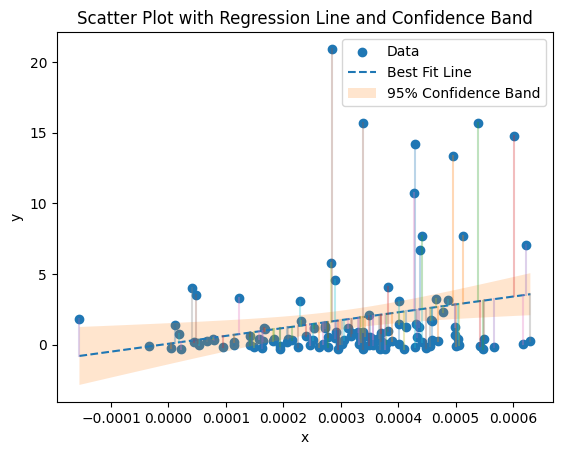

In [8]:
import statsmodels.api as sm

x = join_dfs["MSD-Heart"]['attn_diff'].values
y = join_dfs["MSD-Heart"]['dice_diff'].values

# Add constant for intercept
X = sm.add_constant(x)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Create smooth x range for plotting
x_line = np.linspace(x.min(), x.max(), 200)
X_line = sm.add_constant(x_line)

# Predictions + confidence intervals
pred = model.get_prediction(X_line)
pred_mean = pred.predicted_mean
conf_int = pred.conf_int(alpha=0.05)  # 95% CI

lower = conf_int[:, 0]
upper = conf_int[:, 1]

# Plot
plt.figure()

# Scatter
plt.scatter(x, y, label='Data')

# Best fit line
plt.plot(x_line, pred_mean, linestyle='--', label='Best Fit Line')

# Confidence band
plt.fill_between(x_line, lower, upper, alpha=0.2, label='95% Confidence Band')

# Residual lines
y_pred = model.predict(X)
for xi, yi, ypi in zip(x, y, y_pred):
    plt.plot([xi, xi], [yi, ypi], alpha=0.3)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot with Regression Line and Confidence Band')
plt.legend()

plt.show()

In [9]:
# display(eval(dfs["MSD-Heart+FIFO"][dfs["MSD-Heart+FIFO"]["id"] == ""]["delta"].values[0]))

In [10]:
display_cols = [
        "dice_diff",
        "dice_rl",
        "dice_fifo",
        'attn_diff',
        "min_attn_rl",
        "min_attn_fifo",
        "drop_frame_rl",
        "drop_frame_fifo"
]
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#         display(join_dfs["MSD-Heart"].sort_values('dice_diff', ascending=False)[display_cols])

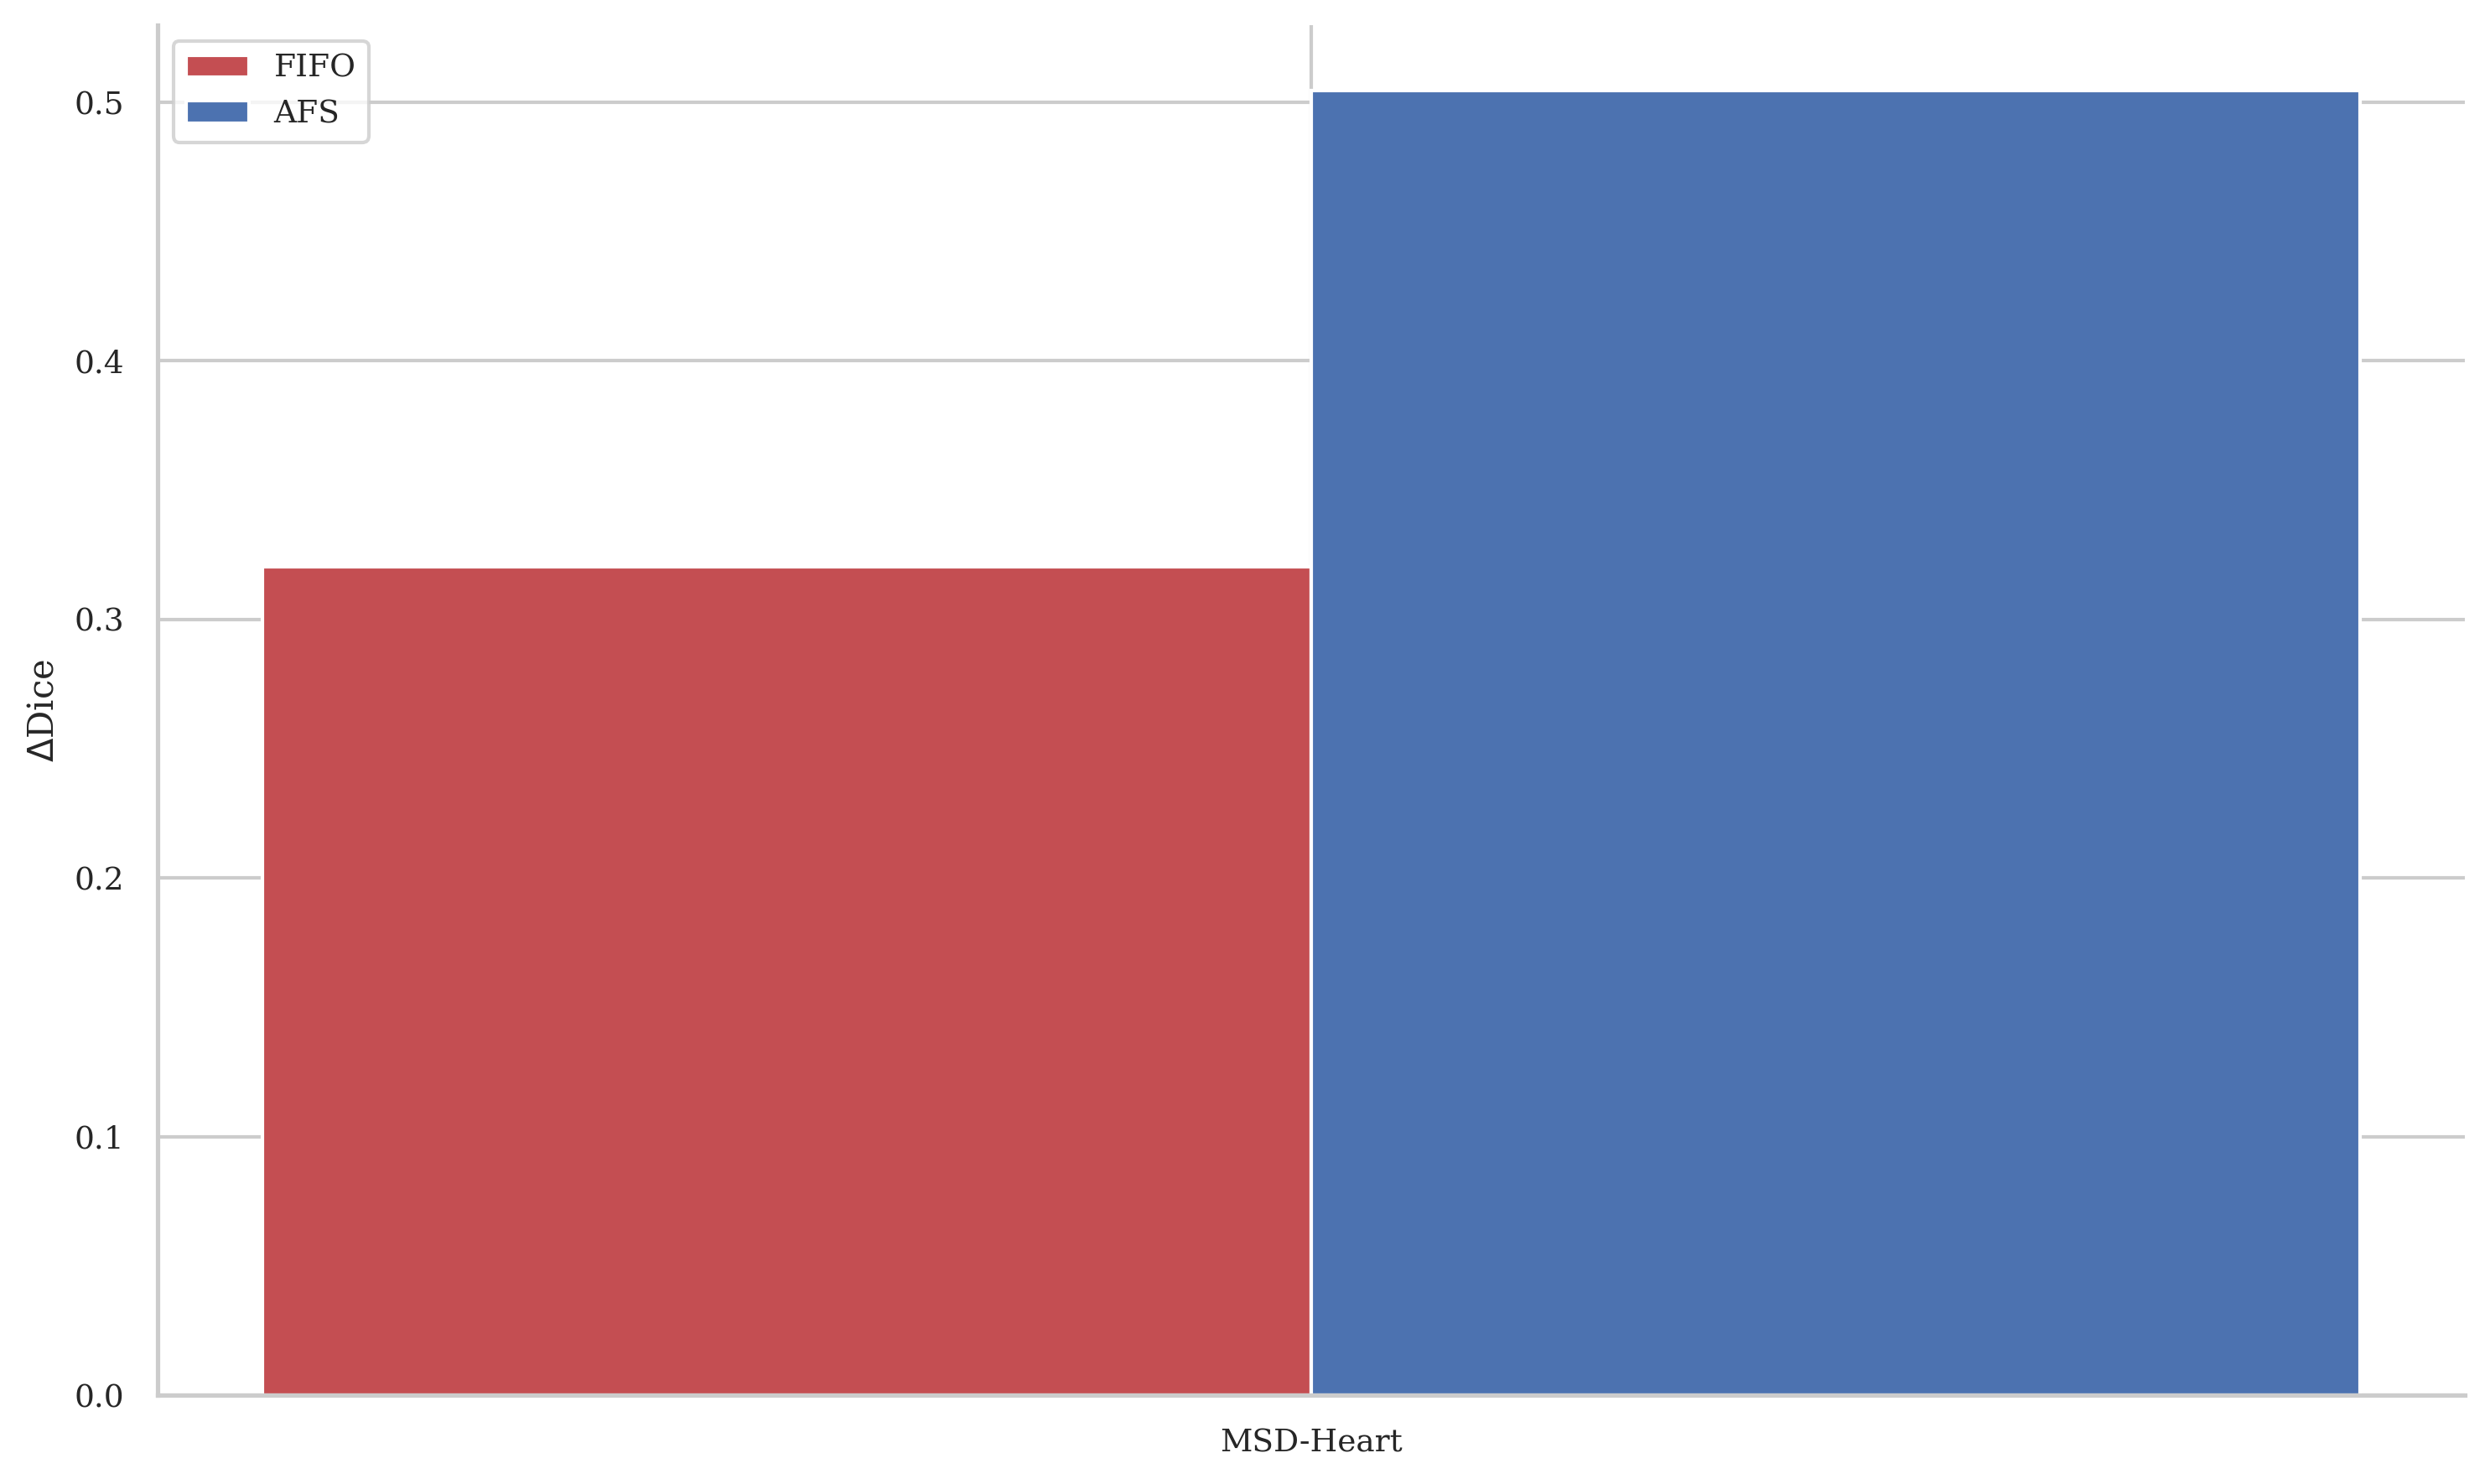

In [11]:
# Set publication-quality style
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.2)
colors = ["#4C72B0", "#C44E52"]
sns.set_palette(sns.color_palette(colors))
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300
})

# Example data structure
# datasets = ['Sarcoma', 'MSD-Heart', 'MSD-Prostate', 'MSD-Spleen', 'MSD-Colon']
datasets = ['MSD-Heart']
# fifo_vals = [v.median() for k, v in mean_delta.items() if "FIFO" in k]
# afs_vals = [v.median() for k, v in mean_delta.items() if "AFS" in k]

fifo_vals = [mean_delta[d + "+FIFO"].mean() for d in datasets]
afs_vals = [mean_delta[d + "+AFS"].mean() for d in datasets]


# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
x = range(len(datasets))

ax.bar([i - width/2 for i in x], fifo_vals, width, label='FIFO', color='r')
ax.bar([i + width/2 for i in x], afs_vals, width, label='AFS', color='b')
ax.set_ylabel(r'$\Delta$Dice') # LaTeX formatting
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend(frameon=True, loc='upper left')
sns.despine() # Removes unnecessary top/right borders
plt.tight_layout()
# plt.savefig("output/quantitative.pdf")

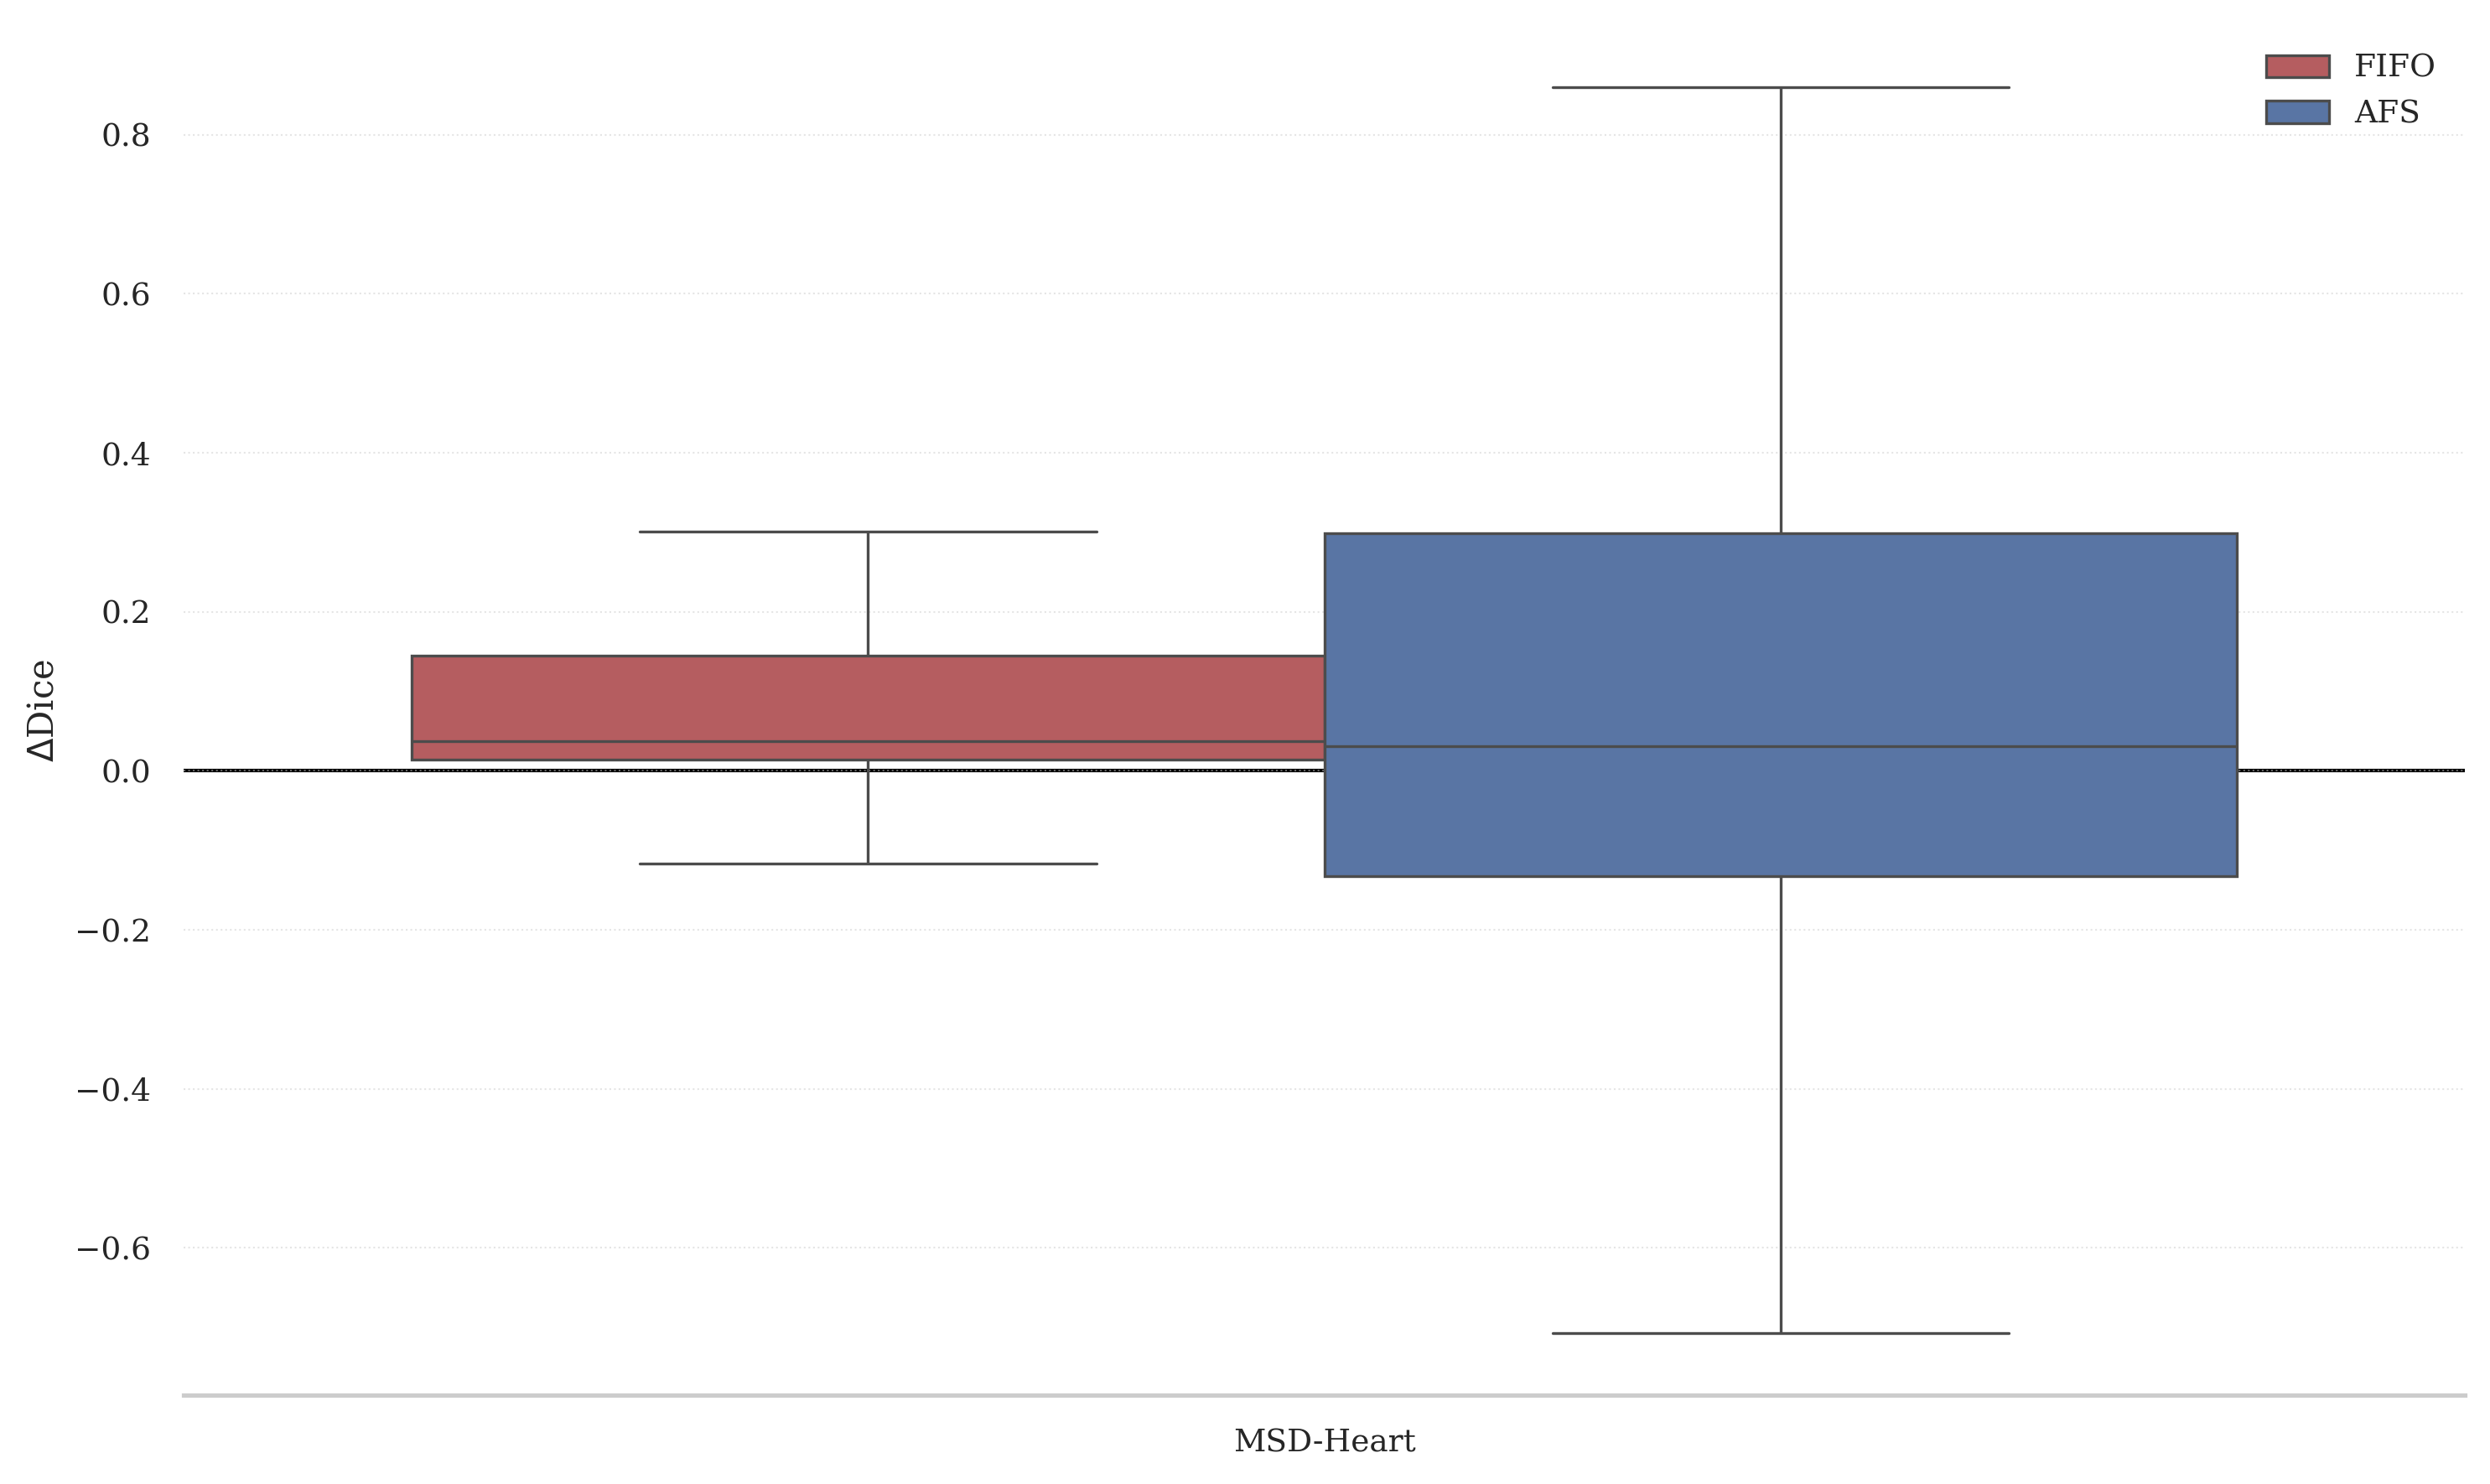

In [12]:
# Set publication-quality style
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.2)
colors = ["#C44E52", "#4C72B0"]
sns.set_palette(sns.color_palette(colors))
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300
})

# 1. Setup synthetic data (simulating distributions around your previous means)
np.random.seed(42)
# datasets = ['Sarcoma', 'MSD-Heart', 'MSD-Prostate', 'MSD-Spleen', 'MSD-Colon']

datasets = ['MSD-Heart']

data = []
# Means from your previous chart
fifo_means = [0.85, 2.9, 2.1, 1.45]
afs_means = [-0.1, 1.35, 0.3, 1.38]

for ds in datasets:
    # Generating distribution data
    data.extend([{'Dataset': ds, 'Method': 'FIFO', 'DeltaDice': v} for v in mean_delta[ds+"+FIFO"]])
    data.extend([{'Dataset': ds, 'Method': 'AFS', 'DeltaDice': v} for v in mean_delta[ds+"+AFS"]])

df = pd.DataFrame(data)

# 3. Create the Boxplot
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Dataset',
    y='DeltaDice',
    hue='Method',
    palette=colors,
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3},
    showfliers=False, # Show outliers
    linewidth=0.8,
    ax=ax
)

# Professional tweaks
ax.axhline(0, color='black', linestyle='-', linewidth=1, zorder=0)
ax.set_ylabel(r'$\Delta$Dice')
ax.set_xlabel('') # Often dataset names on x-axis are self-explanatory
sns.despine(left=True) # Clean look
ax.grid(axis='y', linestyle=':', alpha=0.5, linewidth=0.5)
ax.set_axisbelow(True) # Ensure grid is behind the boxes
plt.legend(frameon=False, loc="best")
plt.tight_layout()

# Save as vector for final paper
# plt.savefig('output/quantitative-box.pdf', bbox_inches='tight')
# plt.show()

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---- GLOBAL STYLE ----
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelweight": "bold",
    "axes.linewidth": 1.2,
    "pdf.fonttype": 42,  # Editable text in Illustrator
    "ps.fonttype": 42,
})

# ---- Example Data Structure ----
# Replace with your real data
datasets = ['Sarcoma', 'MSD-Heart', 'MSD-Prostate', 'MSD-Spleen', 'MSD-Colon']
methods = ["FIFO", "AFS"]

data = []
for ds in datasets:
    # Generating distribution data
    data.extend([{'Dataset': ds, 'Method': 'FIFO', 'DeltaDice': v} for v in mean_delta[ds+"+FIFO"]])
    data.extend([{'Dataset': ds, 'Method': 'AFS', 'DeltaDice': v} for v in mean_delta[ds+"+AFS"]])

df = pd.DataFrame(data, columns=["Dataset", "Method", "DeltaDice"])

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 8))

palette = {
    "FIFO": "#4C72B0",
    "AFS": "#DD8452"
}

sns.boxplot(
    data=df,
    x="Dataset",
    y="DeltaDice",
    hue="Method",
    palette=palette,
    width=0.6,
    linewidth=1.5,
    fliersize=2,
    ax=ax
)

sns.stripplot(
    data=df,
    x="Dataset",
    y="DeltaDice",
    hue="Method",
    dodge=True,
    color="black",
    size=2,
    alpha=0.3,
    ax=ax
)

# Remove duplicate legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], frameon=False, fontsize=10)

# Improve axis
ax.set_ylabel("Dice Score ↑", fontsize=12, weight="bold")
ax.set_xlabel("")
# ax.set_ylim(0.6, 0.95)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("quantitative_box_eccv.pdf", dpi=600, bbox_inches="tight")
plt.show()

KeyError: 'Sarcoma+FIFO'